# Blocking with Bush–Mosteller and Rescorla–Wagner

> **Level** Beginner · **Time** 15 minutes · **Prerequisites** none ·
> **cpm components** [`SeparableRule`](#cpm.models.learning.SeparableRule), [`DeltaRule`](#cpm.models.learning.DeltaRule), [`Nominal`](#cpm.models.utils.Nominal), [`Wrapper`](#cpm.generators.Wrapper), [`Simulator`](#cpm.generators.Simulator) ·
> **Data** a simulated blocking experiment

Blocking (Kamin, 1969) is a classic cue competition effect in associative learning: when a cue has already been learned to predict an outcome, a new cue presented together with it gains little associative strength.
It was one of the original targets of the Rescorla–Wagner model (Rescorla & Wagner, 1972), and it distinguishes that model from its predecessor, the linear operator model of Bush and Mosteller (1951).

In this example, we simulate a blocking experiment with both learning rules, and show why only one of them predicts blocking.

**What you'll learn**

- how to represent the cues of a trial with [`Nominal`](#cpm.models.utils.Nominal),
- the difference between a separable error term ([`SeparableRule`](#cpm.models.learning.SeparableRule)) and a summed error term ([`DeltaRule`](#cpm.models.learning.DeltaRule)),
- how to run a model over an experiment with a [`Wrapper`](#cpm.generators.Wrapper), and over many parameter values with a [`Simulator`](#cpm.generators.Simulator).

In [1]:
import cpm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(cpm.__version__)

0.25.7.dev0


## The blocking design

We use four cues: A, B, X and Y.
In the first phase, cue A is followed by the outcome (A+), and cue Y is not (Y−).
In the second phase, both A and Y are presented in compound with a new cue: AB is followed by the outcome (AB+), and so is XY (XY+).

| Phase 1 | Phase 2 | Test |
|---|---|---|
| A+, Y− | AB+, XY+ | B vs X |

Both B and X were followed by the outcome equally often, but B was always paired with A, which already predicted the outcome.
If learning is blocked, B ends up with less associative strength than the control cue X.

We write the design as a table, with one row per trial.
The cues present on a trial are in `cue_1` and `cue_2` (0 means no second cue), numbered A = 1, B = 2, X = 3, Y = 4, and `outcome` is 1 if the outcome followed.

In [2]:
cue_names = ["A", "B", "X", "Y"]

phase_1 = [{"phase": 1, "cue_1": 1, "cue_2": 0, "outcome": 1}, {"phase": 1, "cue_1": 4, "cue_2": 0, "outcome": 0}] * 10
phase_2 = [{"phase": 2, "cue_1": 1, "cue_2": 2, "outcome": 1}, {"phase": 2, "cue_1": 3, "cue_2": 4, "outcome": 1}] * 10
design = pd.DataFrame(phase_1 + phase_2)
design["trial"] = np.arange(1, len(design) + 1)
design["observed"] = design["outcome"]  # what the model predicts
design.head()

,phase,cue_1,cue_2,outcome,trial,observed
0,1,1,0,1,1,1
1,1,4,0,0,2,0
2,1,1,0,1,3,1
3,1,4,0,0,4,0
4,1,1,0,1,5,1


## Two learning rules

In both models, $V_i$ is the associative strength of cue $i$, $R$ is the outcome, and $\alpha$ is the learning rate, which we assume is the same for all cues.
The models only differ in the error term that drives learning.

**Bush and Mosteller (1951).** Each cue that is present learns from its own error, independently of the other cues:

$$
\Delta V_i = \alpha \, (R - V_i)
$$

**Rescorla and Wagner (1972).** All cues that are present share one error, the difference between the outcome and their summed prediction:

$$
\Delta V_i = \alpha \left( R - \sum_{j \in \text{present}} V_j \right)
$$

In cpm, these are [`SeparableRule`](#cpm.models.learning.SeparableRule) and [`DeltaRule`](#cpm.models.learning.DeltaRule).
Both take the current associative strengths (`weights`), the outcome (`feedback`), and a vector that marks which cues are present (`input`), which we build with [`Nominal`](#cpm.models.utils.Nominal).

In [3]:
from cpm.models.learning import DeltaRule, SeparableRule
from cpm.models.utils import Nominal

# which cues are present when A and B are shown together
Nominal(target=np.array([1, 2]), bits=4)

array([1., 1., 0., 0.])

We write one model function, and pass it the learning rule to use.
On each trial, the model predicts the outcome from the summed strength of the cues present, then updates the strengths.

In [4]:
from functools import partial

from cpm.generators import Parameters, Wrapper


def model(parameters, trial, rule):
    values = np.asarray(parameters.values).copy()
    cues = np.array([trial.cue_1, trial.cue_2])
    present = Nominal(target=cues[cues > 0], bits=4)

    prediction = np.sum(values * present)
    update = rule(weights=values, feedback=[trial.outcome], input=present, alpha=parameters.alpha)
    update.compute()
    values += update.weights.flatten()

    return {"values": values, "prediction": prediction, "dependent": np.array([prediction])}


parameters = Parameters(alpha=0.2, values=np.zeros(4))
rules = {"Bush and Mosteller": SeparableRule, "Rescorla and Wagner": DeltaRule}

## Running the experiment

A [`Wrapper`](#cpm.generators.Wrapper) runs a model over all trials of one experiment.
We run it once for each learning rule, and plot how the associative strength of each cue develops.

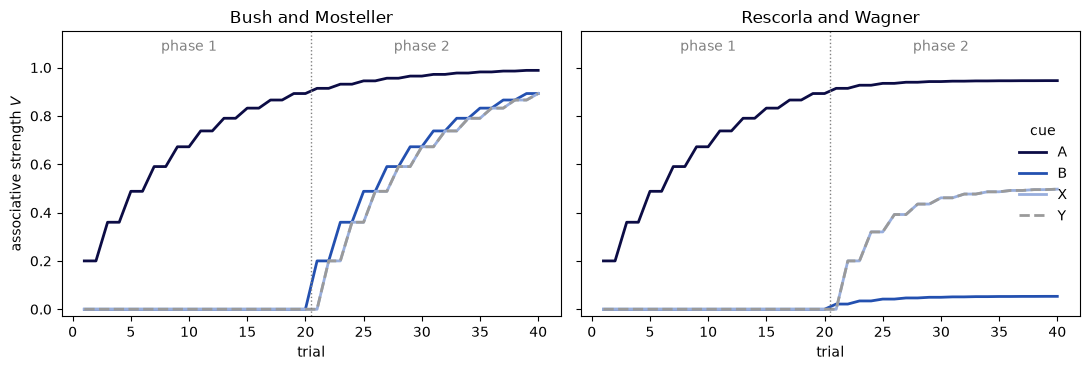

In [5]:
results = {}
for name, rule in rules.items():
    wrapper = Wrapper(model=partial(model, rule=rule), parameters=parameters, data=design)
    wrapper.run()
    results[name] = wrapper.export()

colours = {"A": "#0c0c45", "B": "#2350b0", "X": "#98aedd", "Y": "#9a9a9a"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, (name, output) in zip(axes, results.items()):
    for i, cue in enumerate(cue_names):
        style = "--" if cue == "Y" else "-"
        ax.plot(design.trial, output[f"values_{i}"], label=cue, color=colours[cue], linewidth=2, linestyle=style)
    ax.axvline(20.5, color="grey", linestyle=":", linewidth=1)
    ax.text(10, 1.07, "phase 1", ha="center", color="grey")
    ax.text(30, 1.07, "phase 2", ha="center", color="grey")
    ax.set_ylim(-0.03, 1.15)
    ax.set_title(name)
    ax.set_xlabel("trial")
axes[0].set_ylabel("associative strength $V$")
axes[1].legend(title="cue", frameon=False, loc="center right")
plt.tight_layout()
plt.show()

In phase 1, both models learn that A predicts the outcome and Y does not.
In phase 2, the models diverge:

- In the Bush–Mosteller model, each cue learns on its own, so B and X both grow towards the outcome at the same rate.
- In the Rescorla–Wagner model, A already predicts the outcome when AB is presented, so the shared error is close to zero and B learns very little. X is paired with Y, which predicts nothing, so X and Y share a large error, and each gains about half of the associative strength that the outcome supports (their lines overlap).

## The test

At test, we compare the associative strength of the blocked cue B with the control cue X at the end of training.

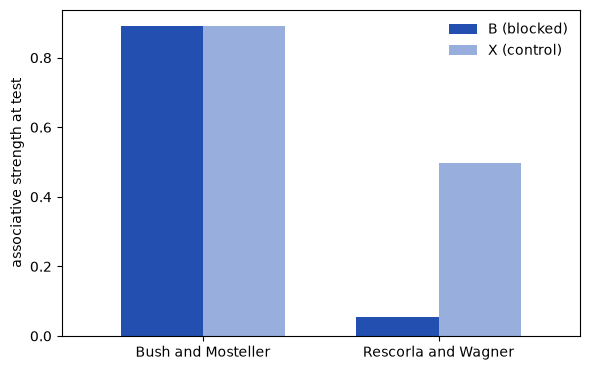

In [6]:
test = pd.DataFrame(
    {name: output.iloc[-1][["values_1", "values_2"]].to_numpy() for name, output in results.items()},
    index=["B (blocked)", "X (control)"],
)

fig, ax = plt.subplots(figsize=(6, 3.8))
test.T.plot.bar(ax=ax, color=[colours["B"], colours["X"]], rot=0, width=0.7)
ax.set_ylabel("associative strength at test")
ax.set_xlabel("")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [7]:
test.round(3)

,Bush and Mosteller,Rescorla and Wagner
B (blocked),0.893,0.053
X (control),0.893,0.497


Only the Rescorla–Wagner model predicts blocking: B ends up with much less associative strength than X.

## Does this depend on the learning rate?

A [`Simulator`](#cpm.generators.Simulator) runs a model for many parameter sets at once.
We run both models for a range of learning rates, and measure the size of the blocking effect as the difference between X and B at test.

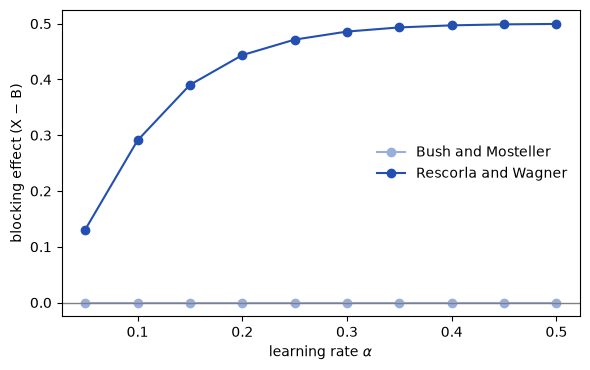

In [8]:
from cpm.generators import Simulator

learning_rates = np.linspace(0.05, 0.5, 10)
sweep = [{"alpha": alpha, "values": np.zeros(4)} for alpha in learning_rates]
# every simulated agent runs the same experiment
experiments = pd.concat([design.assign(agent=i) for i in range(len(learning_rates))])

fig, ax = plt.subplots(figsize=(6, 3.8))
for (name, rule), colour in zip(rules.items(), ["#98aedd", "#2350b0"]):
    simulator = Simulator(
        wrapper=Wrapper(model=partial(model, rule=rule), parameters=parameters, data=design),
        parameters=sweep,
        data=experiments.groupby("agent"),
    )
    simulator.run()
    final = simulator.export().groupby("ppt").last()
    blocking = final["values_2"] - final["values_1"]
    ax.plot(learning_rates, blocking.to_numpy(), marker="o", label=name, color=colour)
ax.axhline(0, color="grey", linewidth=1)
ax.set_xlabel(r"learning rate $\alpha$")
ax.set_ylabel("blocking effect (X − B)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

For every learning rate, the Bush–Mosteller model predicts no blocking at all.
The Rescorla–Wagner model predicts blocking for every learning rate, and the effect grows with the learning rate: when learning is slow, A is not fully learned by the end of phase 1, so it leaves some of the outcome unpredicted, and B can still gain some strength in phase 2.

## Summary and next steps

You simulated a blocking experiment with two learning rules, and showed that blocking follows from the shared, summed error term of the Rescorla–Wagner model.
To fit models like these to the choices of participants, start with [Tutorial 1: Build and fit your first model](../tutorials/first-model.ipynb).

## References

Bush, R. R., & Mosteller, F. (1951). A mathematical model for simple learning. *Psychological Review*, 58(5), 313–323. https://doi.org/10.1037/h0054388

Kamin, L. J. (1969). Predictability, surprise, attention, and conditioning. In B. A. Campbell & R. M. Church (Eds.), *Punishment and aversive behavior* (pp. 279–296). Appleton-Century-Crofts.

Rescorla, R. A., & Wagner, A. R. (1972). A theory of Pavlovian conditioning: Variations in the effectiveness of reinforcement and nonreinforcement. In A. H. Black & W. F. Prokasy (Eds.), *Classical conditioning II: Current research and theory* (pp. 64–99). Appleton-Century-Crofts.